In [4]:
!rm -rf clone && git clone https://github.com/ferit-osirv/lab3 clone && cp -a clone/. .

Cloning into 'clone'...
remote: Enumerating objects: 43, done.
remote: Counting objects: 100% (26/26), done.
remote: Compressing objects: 100% (25/25), done.
remote: Total 43 (delta 2), reused 20 (delta 1), pack-reused 17 (from 1)
Receiving objects: 100% (43/43), 10.11 MiB | 23.54 MiB/s, done.
Resolving deltas: 100% (3/3), done.


In [5]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

In [ ]:
# Task 1

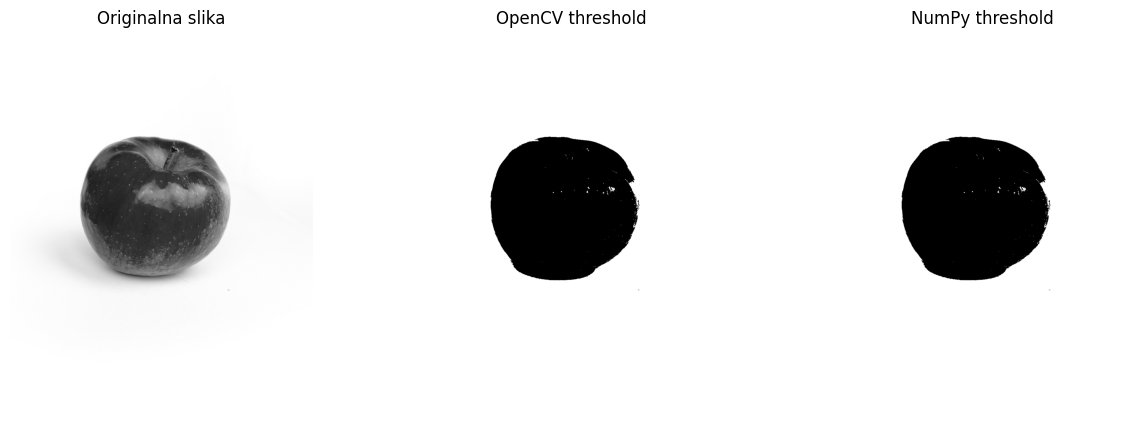

In [8]:
# Učitavanje grayscale slike
img = cv.imread('images/apple.jpg', cv.IMREAD_GRAYSCALE)

# Odabran prag
threshold_value = 170

# OpenCV simple thresholding
ret, thresh_cv = cv.threshold(img, threshold_value, 255, cv.THRESH_BINARY)

# NumPy implementacija thresholdinga
thresh_np = np.where(img > threshold_value, 255, 0).astype(np.uint8)

# prikaz rezultata
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title('Originalna slika')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(thresh_cv, cmap='gray')
plt.title('OpenCV threshold')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(thresh_np, cmap='gray')
plt.title('NumPy threshold')
plt.axis('off')

plt.show()

In [ ]:
# Task 2

Otsu threshold: 165.0


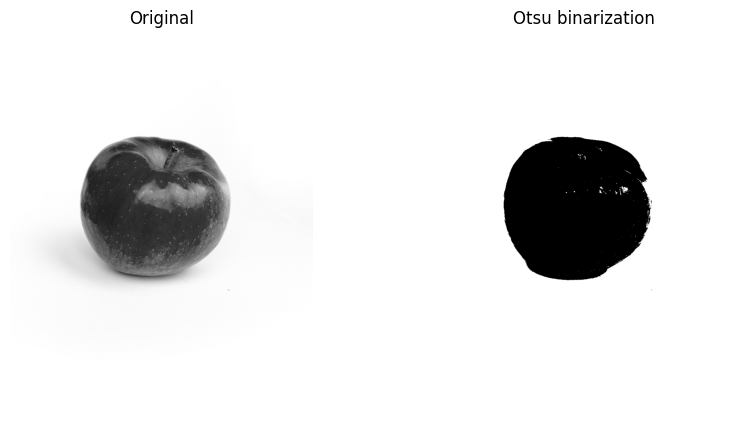

In [9]:
# Otsu binarizacija (OpenCV automatski bira threshold)
otsu_value, img_otsu = cv.threshold(
    img, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU
)

# ispis optimalnog thresholda
print("Otsu threshold:", otsu_value)

# prikaz rezultata
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img_otsu, cmap='gray')
plt.title("Otsu binarization")
plt.axis('off')

plt.show()

In [ ]:
# Task 3

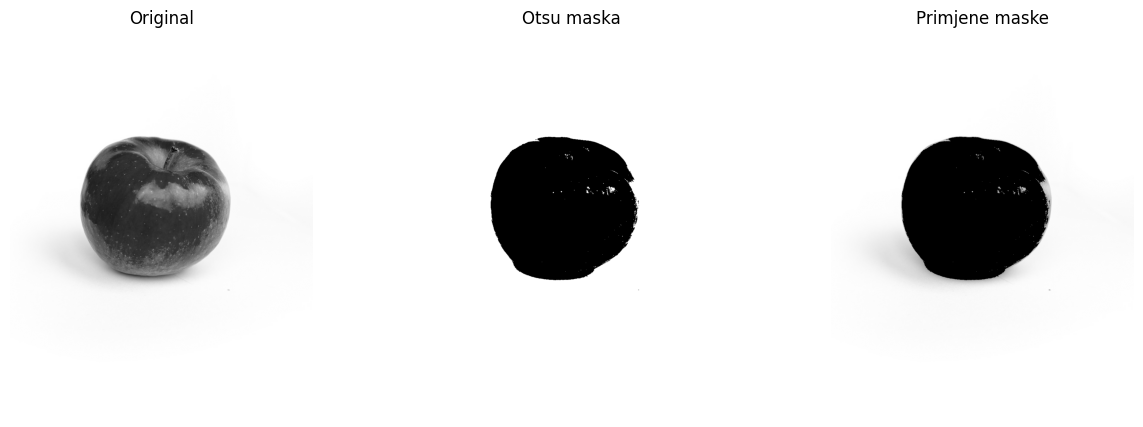

In [12]:
# Otsu binarizacija
otsu_value, otsu_mask = cv.threshold(
    img, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU
)

# primjena maske na originalnu sliku
img_masked = cv.bitwise_and(img, img, mask=otsu_mask)

# prikaz
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(otsu_mask, cmap='gray')
plt.title("Otsu maska")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(img_masked, cmap='gray')
plt.title("Primjene maske")
plt.axis('off')

plt.show()

In [ ]:
# Task 4

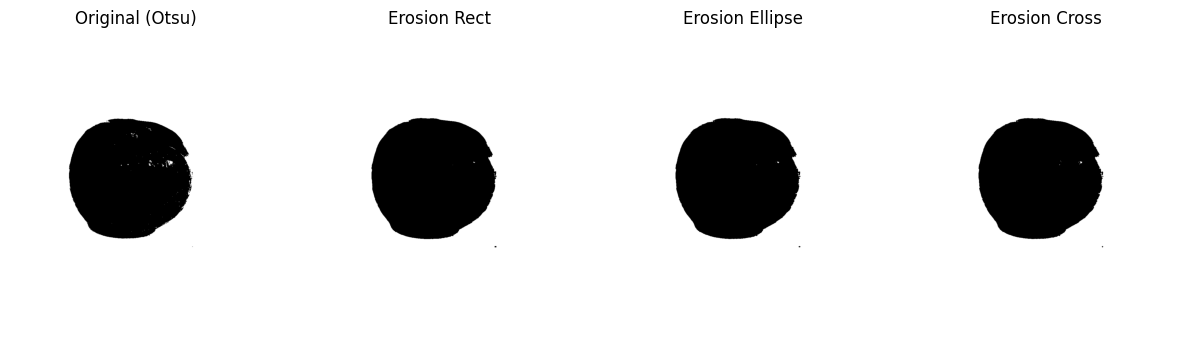

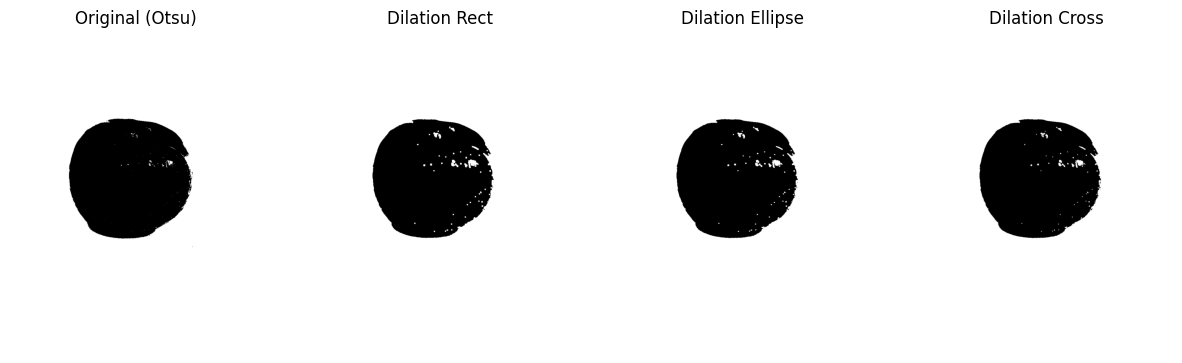

In [13]:
# koristimo Otsu masku kao binarnu sliku
otsu_value, img_bin = cv.threshold(
    img, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU
)

# kerneli (structuring elements)
kernel_rect = cv.getStructuringElement(cv.MORPH_RECT, (5,5))
kernel_ellipse = cv.getStructuringElement(cv.MORPH_ELLIPSE, (5,5))
kernel_cross = cv.getStructuringElement(cv.MORPH_CROSS, (5,5))

# -------------------------
# EROZIJA
# -------------------------
erode_rect = cv.erode(img_bin, kernel_rect, iterations=1)
erode_ellipse = cv.erode(img_bin, kernel_ellipse, iterations=1)
erode_cross = cv.erode(img_bin, kernel_cross, iterations=1)

plt.figure(figsize=(15,5))

plt.subplot(1,4,1)
plt.imshow(img_bin, cmap='gray')
plt.title("Original (Otsu)")
plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(erode_rect, cmap='gray')
plt.title("Erosion Rect")
plt.axis('off')

plt.subplot(1,4,3)
plt.imshow(erode_ellipse, cmap='gray')
plt.title("Erosion Ellipse")
plt.axis('off')

plt.subplot(1,4,4)
plt.imshow(erode_cross, cmap='gray')
plt.title("Erosion Cross")
plt.axis('off')

plt.show()

# -------------------------
# DILACIJA
# -------------------------
dilate_rect = cv.dilate(img_bin, kernel_rect, iterations=1)
dilate_ellipse = cv.dilate(img_bin, kernel_ellipse, iterations=1)
dilate_cross = cv.dilate(img_bin, kernel_cross, iterations=1)

plt.figure(figsize=(15,5))

plt.subplot(1,4,1)
plt.imshow(img_bin, cmap='gray')
plt.title("Original (Otsu)")
plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(dilate_rect, cmap='gray')
plt.title("Dilation Rect")
plt.axis('off')

plt.subplot(1,4,3)
plt.imshow(dilate_ellipse, cmap='gray')
plt.title("Dilation Ellipse")
plt.axis('off')

plt.subplot(1,4,4)
plt.imshow(dilate_cross, cmap='gray')
plt.title("Dilation Cross")
plt.axis('off')

plt.show()